In [ ]:
import os
import json
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers


_LOAD_HP = None
_LOAD_INPUT_DIM = None



class PlainDNN(tf.keras.Model):
    def __init__(self, input_dim=None, hp=None, **kwargs):
        super().__init__(**kwargs)

        global _LOAD_HP, _LOAD_INPUT_DIM

        if hp is None:
            if _LOAD_HP is None:
                raise ValueError("hp is missing and _LOAD_HP is not available.")
            hp = _LOAD_HP

        if input_dim is None:
            if _LOAD_INPUT_DIM is None:
                raise ValueError("input_dim is missing and _LOAD_INPUT_DIM is not available.")
            input_dim = _LOAD_INPUT_DIM

        self.hp = hp
        self.input_dim_ = int(input_dim)
        self.hidden_blocks = []

        for units in hp["hidden_layers"]:
            block = []
            block.append(
                layers.Dense(
                    units,
                    activation=None if hp["batch_norm"] else hp["activation"],
                    kernel_regularizer=regularizers.l2(hp["l2"])
                )
            )
            if hp["batch_norm"]:
                block.append(layers.BatchNormalization())
                block.append(layers.Activation(hp["activation"]))
            if hp["dropout"] > 0:
                block.append(layers.Dropout(hp["dropout"]))
            self.hidden_blocks.append(block)

        self.out_layer = layers.Dense(1)

        _ = self(tf.zeros((1, self.input_dim_), dtype=tf.float32), training=False)

    def call(self, x, training=False):
        h = x
        for block in self.hidden_blocks:
            for layer in block:
                if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
                    h = layer(h, training=training)
                else:
                    h = layer(h)
        return self.out_layer(h)

    def get_config(self):
        return {
            "input_dim": self.input_dim_,
            "hp": self.hp
        }

    @classmethod
    def from_config(cls, config):
        global _LOAD_HP, _LOAD_INPUT_DIM
        hp = config.get("hp", _LOAD_HP)
        input_dim = config.get("input_dim", _LOAD_INPUT_DIM)
        return cls(input_dim=input_dim, hp=hp)



LOAD_DIR = "./saved_repeated_dnn_ensemble"

with open(os.path.join(LOAD_DIR, "ensemble_config.json"), "r", encoding="utf-8") as f:
    ensemble_config = json.load(f)

with open(os.path.join(LOAD_DIR, "saved_model_index.pkl"), "rb") as f:
    saved_model_info = pickle.load(f)

weight_vector = np.asarray(ensemble_config["weight_vector"], dtype=float)
feature_cols_loaded = ensemble_config["feature_cols"]

print("Ensemble loaded.")
print("Strategy:", ensemble_config["strategy"])
print("Top N:", ensemble_config["top_n"])



def load_plain_dnn_with_fallback(model_path, hp, input_dim):
    global _LOAD_HP, _LOAD_INPUT_DIM
    _LOAD_HP = hp
    _LOAD_INPUT_DIM = int(input_dim)

    try:
        model = tf.keras.models.load_model(
            model_path,
            custom_objects={"PlainDNN": PlainDNN},
            compile=False
        )
        return model
    finally:
        _LOAD_HP = None
        _LOAD_INPUT_DIM = None



loaded_ensemble = []

for info in saved_model_info:
    with open(info["preprocess_path"], "rb") as f:
        preprocess = pickle.load(f)

    with open(info["meta_path"], "r", encoding="utf-8") as f:
        meta = json.load(f)

    hp = meta["hyperparameters"]

    loaded_ensemble.append({
        "label": info["label"],
        "model_path": info["model_path"],
        "preprocess": preprocess,
        "hyperparameters": hp
    })

print(f"Loaded preprocess objects for {len(loaded_ensemble)} models.")

Processing model 1/15: model_01_id4_r1_f4
Processing model 2/15: model_02_id11_r2_f1
Processing model 3/15: model_03_id12_r2_f2
Processing model 4/15: model_04_id13_r2_f3
Processing model 5/15: model_05_id35_r4_f5
Processing model 6/15: model_06_id37_r4_f7
Processing model 7/15: model_07_id43_r5_f3
Processing model 8/15: model_08_id48_r5_f8
Processing model 9/15: model_09_id52_r6_f2
Processing model 10/15: model_10_id57_r6_f7
Processing model 11/15: model_11_id71_r8_f1
Processing model 12/15: model_12_id72_r8_f2
Processing model 13/15: model_13_id77_r8_f7
Processing model 14/15: model_14_id83_r9_f3
Processing model 15/15: model_15_id87_r9_f7

Top 10 important features (mean absolute SHAP across ensemble):
feature
g__DOCK9     4.130074
g__SPTBN1    4.012966
g__RPL36     2.412545
g__DOK3      2.315467
g__HIP1R     2.269070
g__FBL       2.090815
g__CTSD      2.048942
g__GRN       2.041593
g__CUTA      1.834914
g__GPR18     1.805699
g__RBM38     1.793656
g__APEX1     1.759632
g__SIRPG     

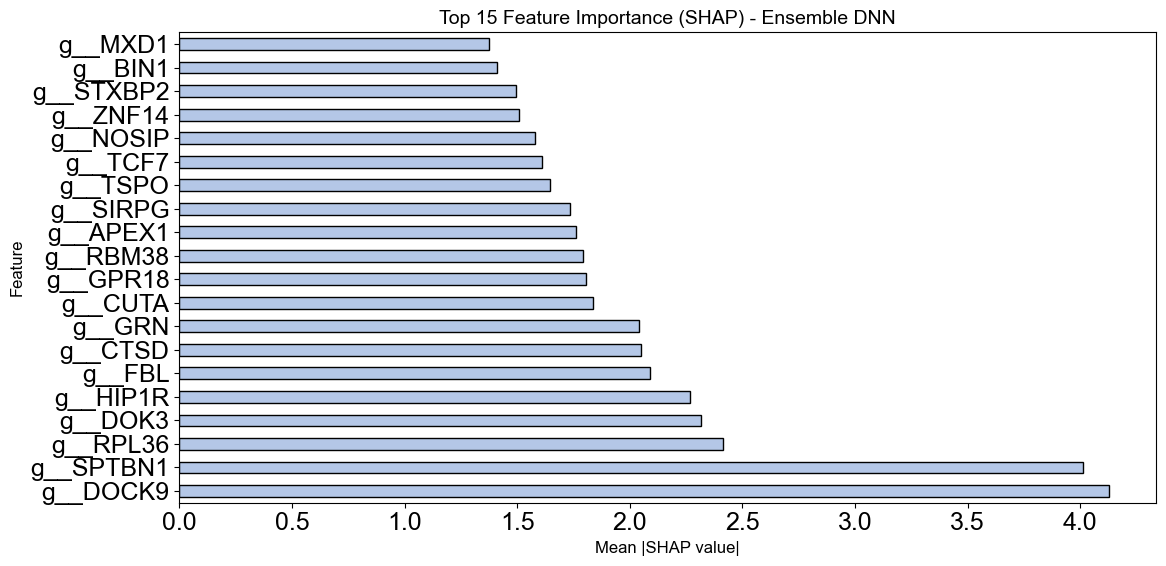


SHAP figure saved to: ./shap_analysis\top10_shap_features.svg


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import tensorflow as tf
import os


SAVE_DIR = "./shap_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)


X_shap = X_train_raw[feature_cols_loaded].copy()
y_shap = np.asarray(y_train)

MAX_SAMPLES = 10000
if X_shap.shape[0] > MAX_SAMPLES:
    idx_sample = np.random.choice(X_shap.index, MAX_SAMPLES, replace=False)
    X_shap_subset = X_shap.loc[idx_sample]
else:
    X_shap_subset = X_shap


feature_importance_list = []

for m_idx, mdl_info in enumerate(loaded_ensemble, start=1):
    print(f"Processing model {m_idx}/{len(loaded_ensemble)}: {mdl_info['label']}")

    model = load_plain_dnn_with_fallback(
        mdl_info["model_path"],
        mdl_info["hyperparameters"],
        input_dim=len(feature_cols_loaded)
    )
    preprocess = mdl_info["preprocess"]

    X_proc = preprocess.transform(X_shap_subset).astype(np.float32)


    input_tensor = tf.keras.Input(shape=(X_proc.shape[1],))
    output_tensor = model(input_tensor)
    wrapped_model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)


    explainer = shap.GradientExplainer(wrapped_model, X_proc)
    shap_values = explainer.shap_values(X_proc)


    shap_values = shap_values[0] if isinstance(shap_values, list) else shap_values

    mean_abs_shap = np.mean(np.abs(shap_values), axis=0).ravel()

    df_feat = pd.DataFrame({
        "feature": feature_cols_loaded,
        "mean_abs_shap": mean_abs_shap,
        "model": mdl_info["label"]
    })
    feature_importance_list.append(df_feat)


feat_imp_all = pd.concat(feature_importance_list)
feat_imp_mean = feat_imp_all.groupby("feature")["mean_abs_shap"].mean().sort_values(ascending=False)
top10_features = feat_imp_mean.head(20)

print("\nTop 10 important features (mean absolute SHAP across ensemble):")
print(top10_features)


top10_features.to_csv(os.path.join(SAVE_DIR, "top10_shap_features.csv"), header=True)


plt.figure(figsize=(12, 6))
top10_features.sort_values().plot(
    kind="barh",
    color="#B4C7E7",
    edgecolor="black"
)
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 15 Feature Importance (SHAP) - Ensemble DNN", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "top10_shap_features.svg")
plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

print(f"\nSHAP figure saved to: {save_path}")


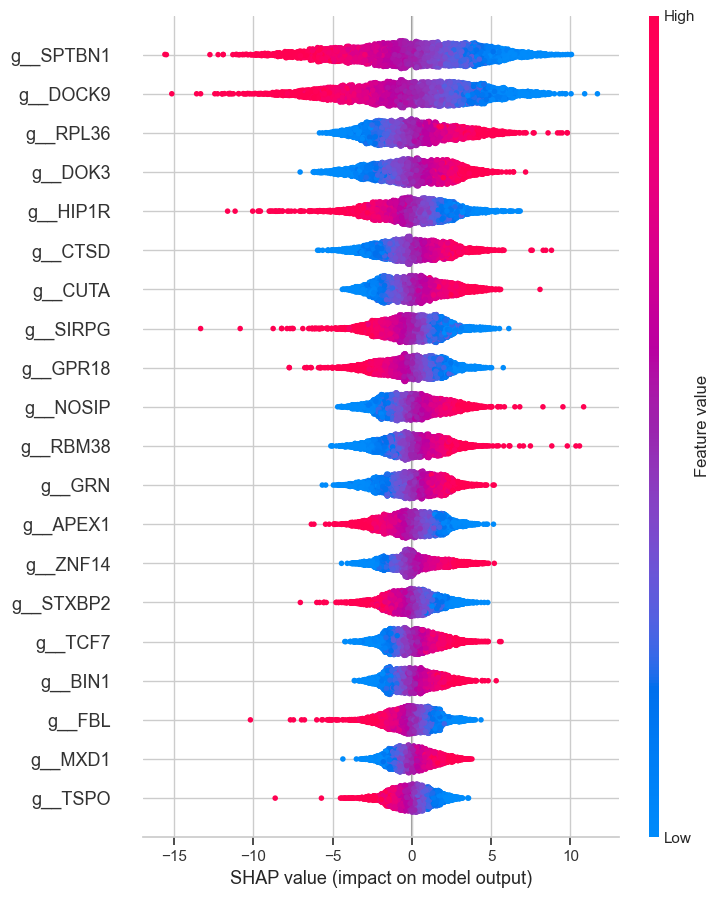

Combined SHAP beeswarm figure saved to: ./shap_analysis\shap_beeswarm_combined.svg


In [438]:
shap_values_combined = []
X_combined_raw = []

for feature in top_features:

    feature_idx = feature_cols_loaded.index(feature)

    shap_values_feature = shap_values[:, feature_idx].reshape(-1, 1)
    shap_values_combined.append(shap_values_feature)
    

    X_feature_raw = X_shap_subset[feature].copy().values.reshape(-1, 1)
    X_combined_raw.append(X_feature_raw)


shap_values_combined = np.hstack(shap_values_combined) 
X_combined_raw = np.hstack(X_combined_raw)  


plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_combined,
    X_combined_raw,
    feature_names=top_features,
    plot_type="dot",  
    show=False  
)

save_path_combined_beeswarm_svg = os.path.join(SAVE_DIR, "shap_beeswarm_combined.svg")
plt.savefig(save_path_combined_beeswarm_svg, format="svg", bbox_inches="tight")
plt.show()

print(f"Combined SHAP beeswarm figure saved to: {save_path_combined_beeswarm_svg}")

In [508]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


N_SAMPLES = 2000         
TOP_N = 20               
EDGE_THRESHOLD = 0.35    
RANDOM_STATE = 42

os.makedirs(SAVE_DIR, exist_ok=True)


top_features = top10_features.index.tolist()[:TOP_N]


top_idx = [feature_cols_loaded.index(f) for f in top_features]


n_total = shap_values.shape[0]
n_use = min(N_SAMPLES, n_total)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(n_total, size=n_use, replace=False)


shap_values_sample = shap_values[sample_idx][:, top_idx]


if shap_values_sample.ndim == 3 and shap_values_sample.shape[-1] == 1:
    shap_values_sample = np.squeeze(shap_values_sample, axis=-1)


X_sample = X_shap_subset.iloc[sample_idx][top_features].copy()

shap_df = pd.DataFrame(
    shap_values_sample,
    columns=top_features,
    index=X_sample.index
)
# =========================


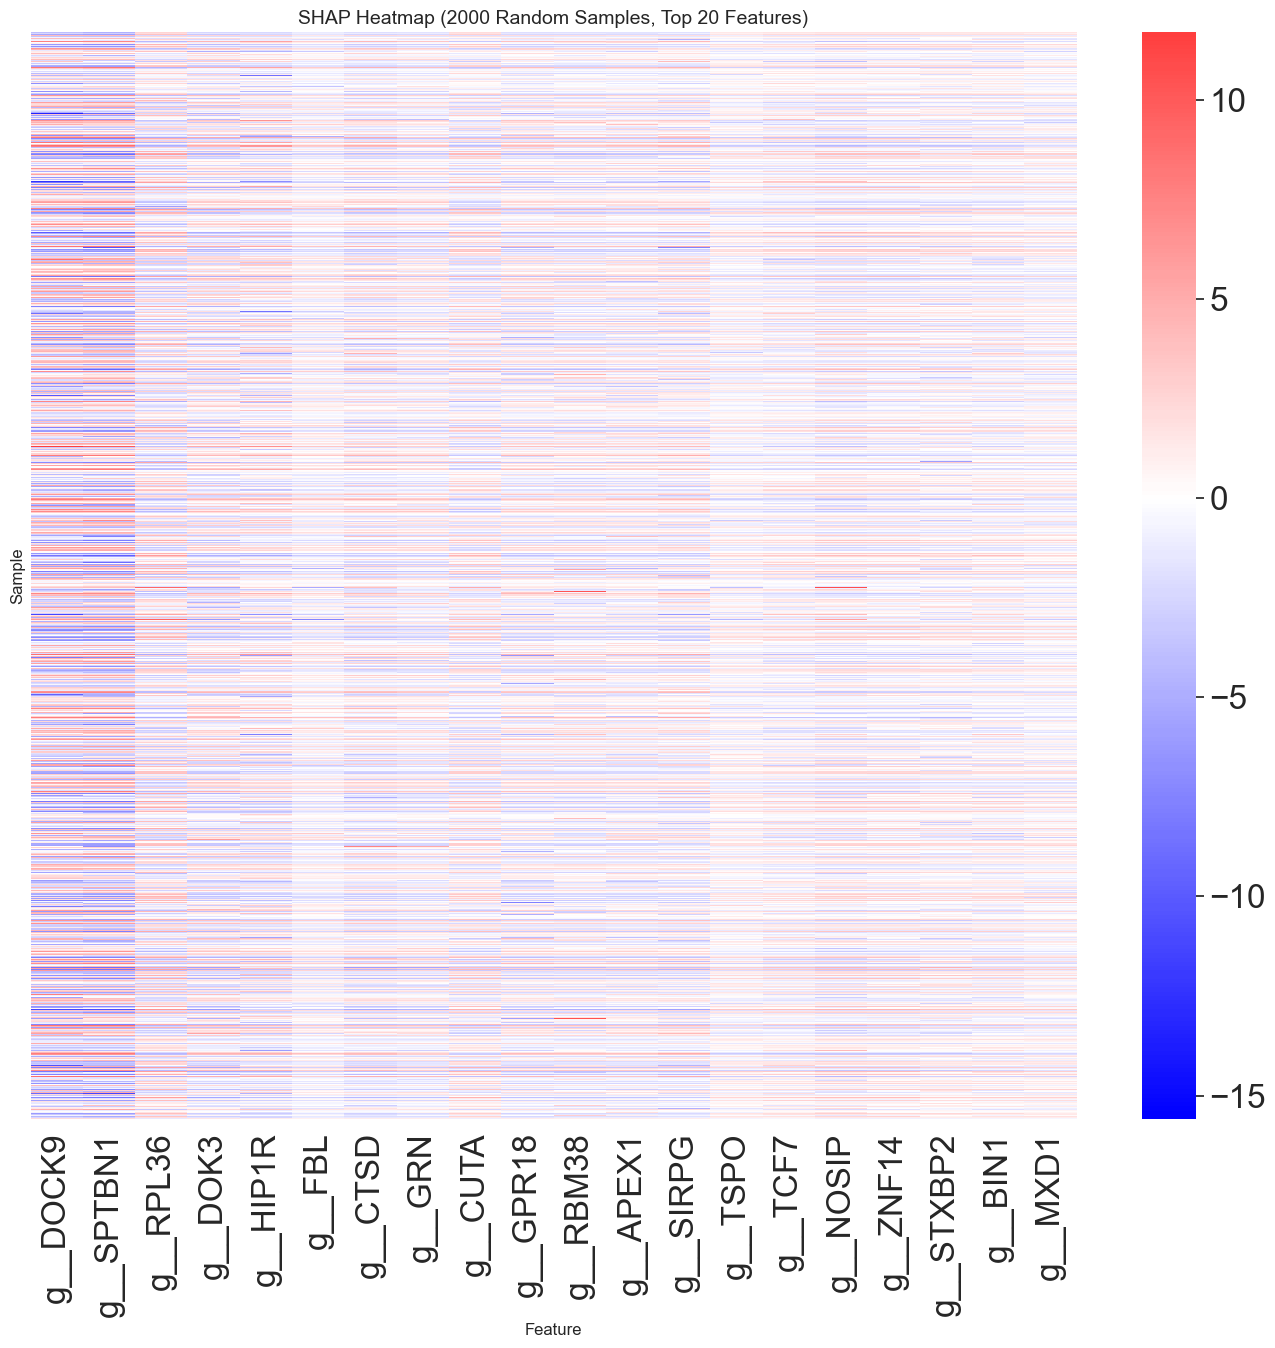

SHAP heatmap saved to: ./shap_analysis\shap_heatmap_top20_2000samples.svg


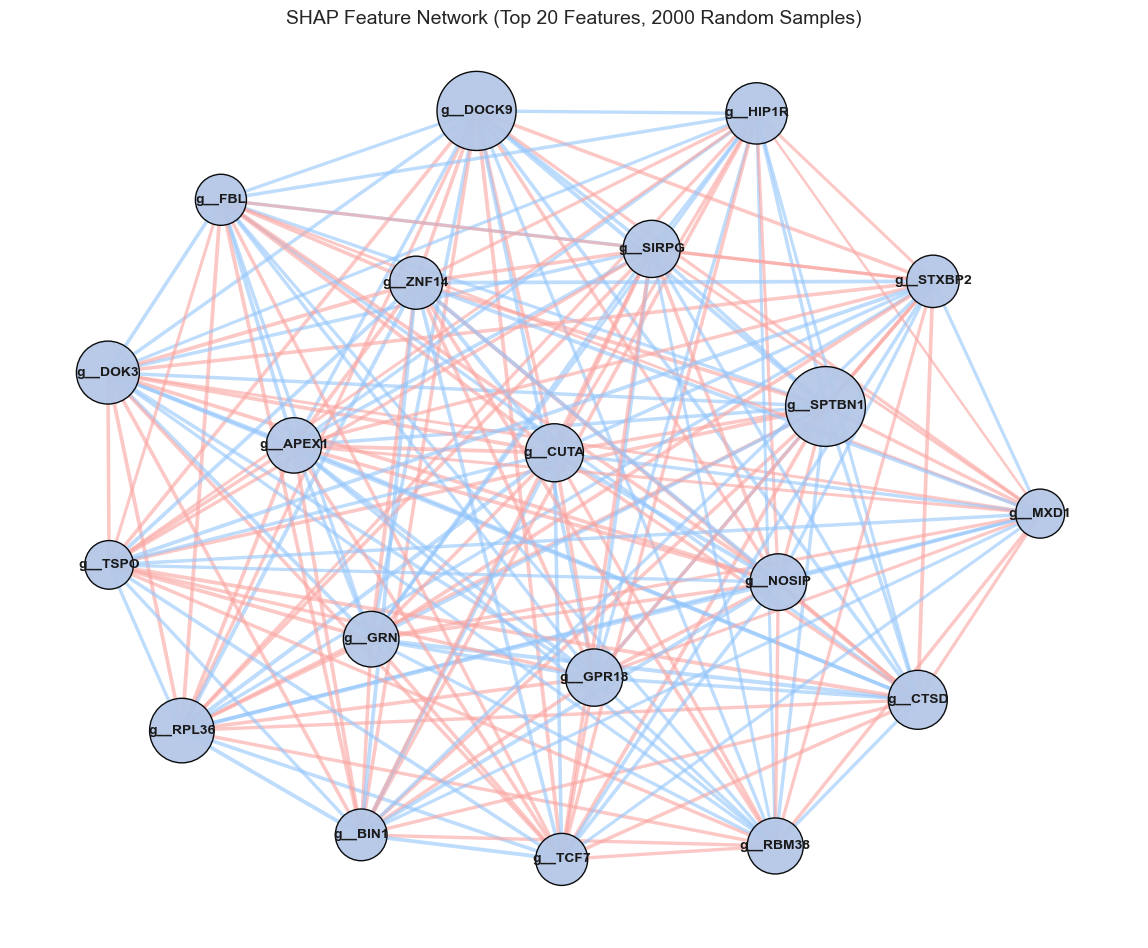

SHAP feature network saved to: ./shap_analysis\shap_feature_network_top20_2000samples.svg


In [516]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap


custom_cmap = LinearSegmentedColormap.from_list(
    "blue_yellow_red", ["blue", "white", "red"]
)


plt.figure(figsize=(14, 14))
sns.heatmap(
    shap_df,
    cmap=custom_cmap,  
    center=0,
    xticklabels=True,
    yticklabels=False
)
plt.title(f"SHAP Heatmap ({n_use} Random Samples, Top {TOP_N} Features)", fontsize=14)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Sample", fontsize=12)
plt.tight_layout()

save_path_heatmap = os.path.join(SAVE_DIR, f"shap_heatmap_top{TOP_N}_{n_use}samples.svg")
plt.savefig(save_path_heatmap, format="svg", bbox_inches="tight")
plt.show()

print(f"SHAP heatmap saved to: {save_path_heatmap}")


corr_matrix = shap_df.corr(method="pearson")


node_importance = shap_df.abs().mean(axis=0)


G = nx.Graph()

for feat in top_features:
    G.add_node(feat, importance=node_importance[feat])


for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        f1 = top_features[i]
        f2 = top_features[j]
        corr_val = corr_matrix.loc[f1, f2]

        if abs(corr_val) >= EDGE_THRESHOLD:
            G.add_edge(f1, f2, weight=abs(corr_val), sign=np.sign(corr_val))


plt.figure(figsize=(12, 10))


pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.8)


node_sizes = [3000 * (G.nodes[n]["importance"] / node_importance.max()) + 300 for n in G.nodes]


edge_widths = [3 * G[u][v]["weight"] for u, v in G.edges]


edge_colors = ["#93C5FB" if G[u][v]["sign"] > 0 else "#FAA4A0" for u, v in G.edges]


nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#B4C7E7", 
    edgecolors="black",
    alpha=0.95
)


nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.6
)


nx.draw_networkx_labels(
    G, pos,
    font_size=10,
    font_weight="bold"
)

plt.title(f"SHAP Feature Network (Top {TOP_N} Features, {n_use} Random Samples)", fontsize=14)
plt.axis("off")
plt.tight_layout()


save_path_network = os.path.join(SAVE_DIR, f"shap_feature_network_top{TOP_N}_{n_use}samples.svg")
plt.savefig(save_path_network, format="svg", bbox_inches="tight")
plt.show()

print(f"SHAP feature network saved to: {save_path_network}")



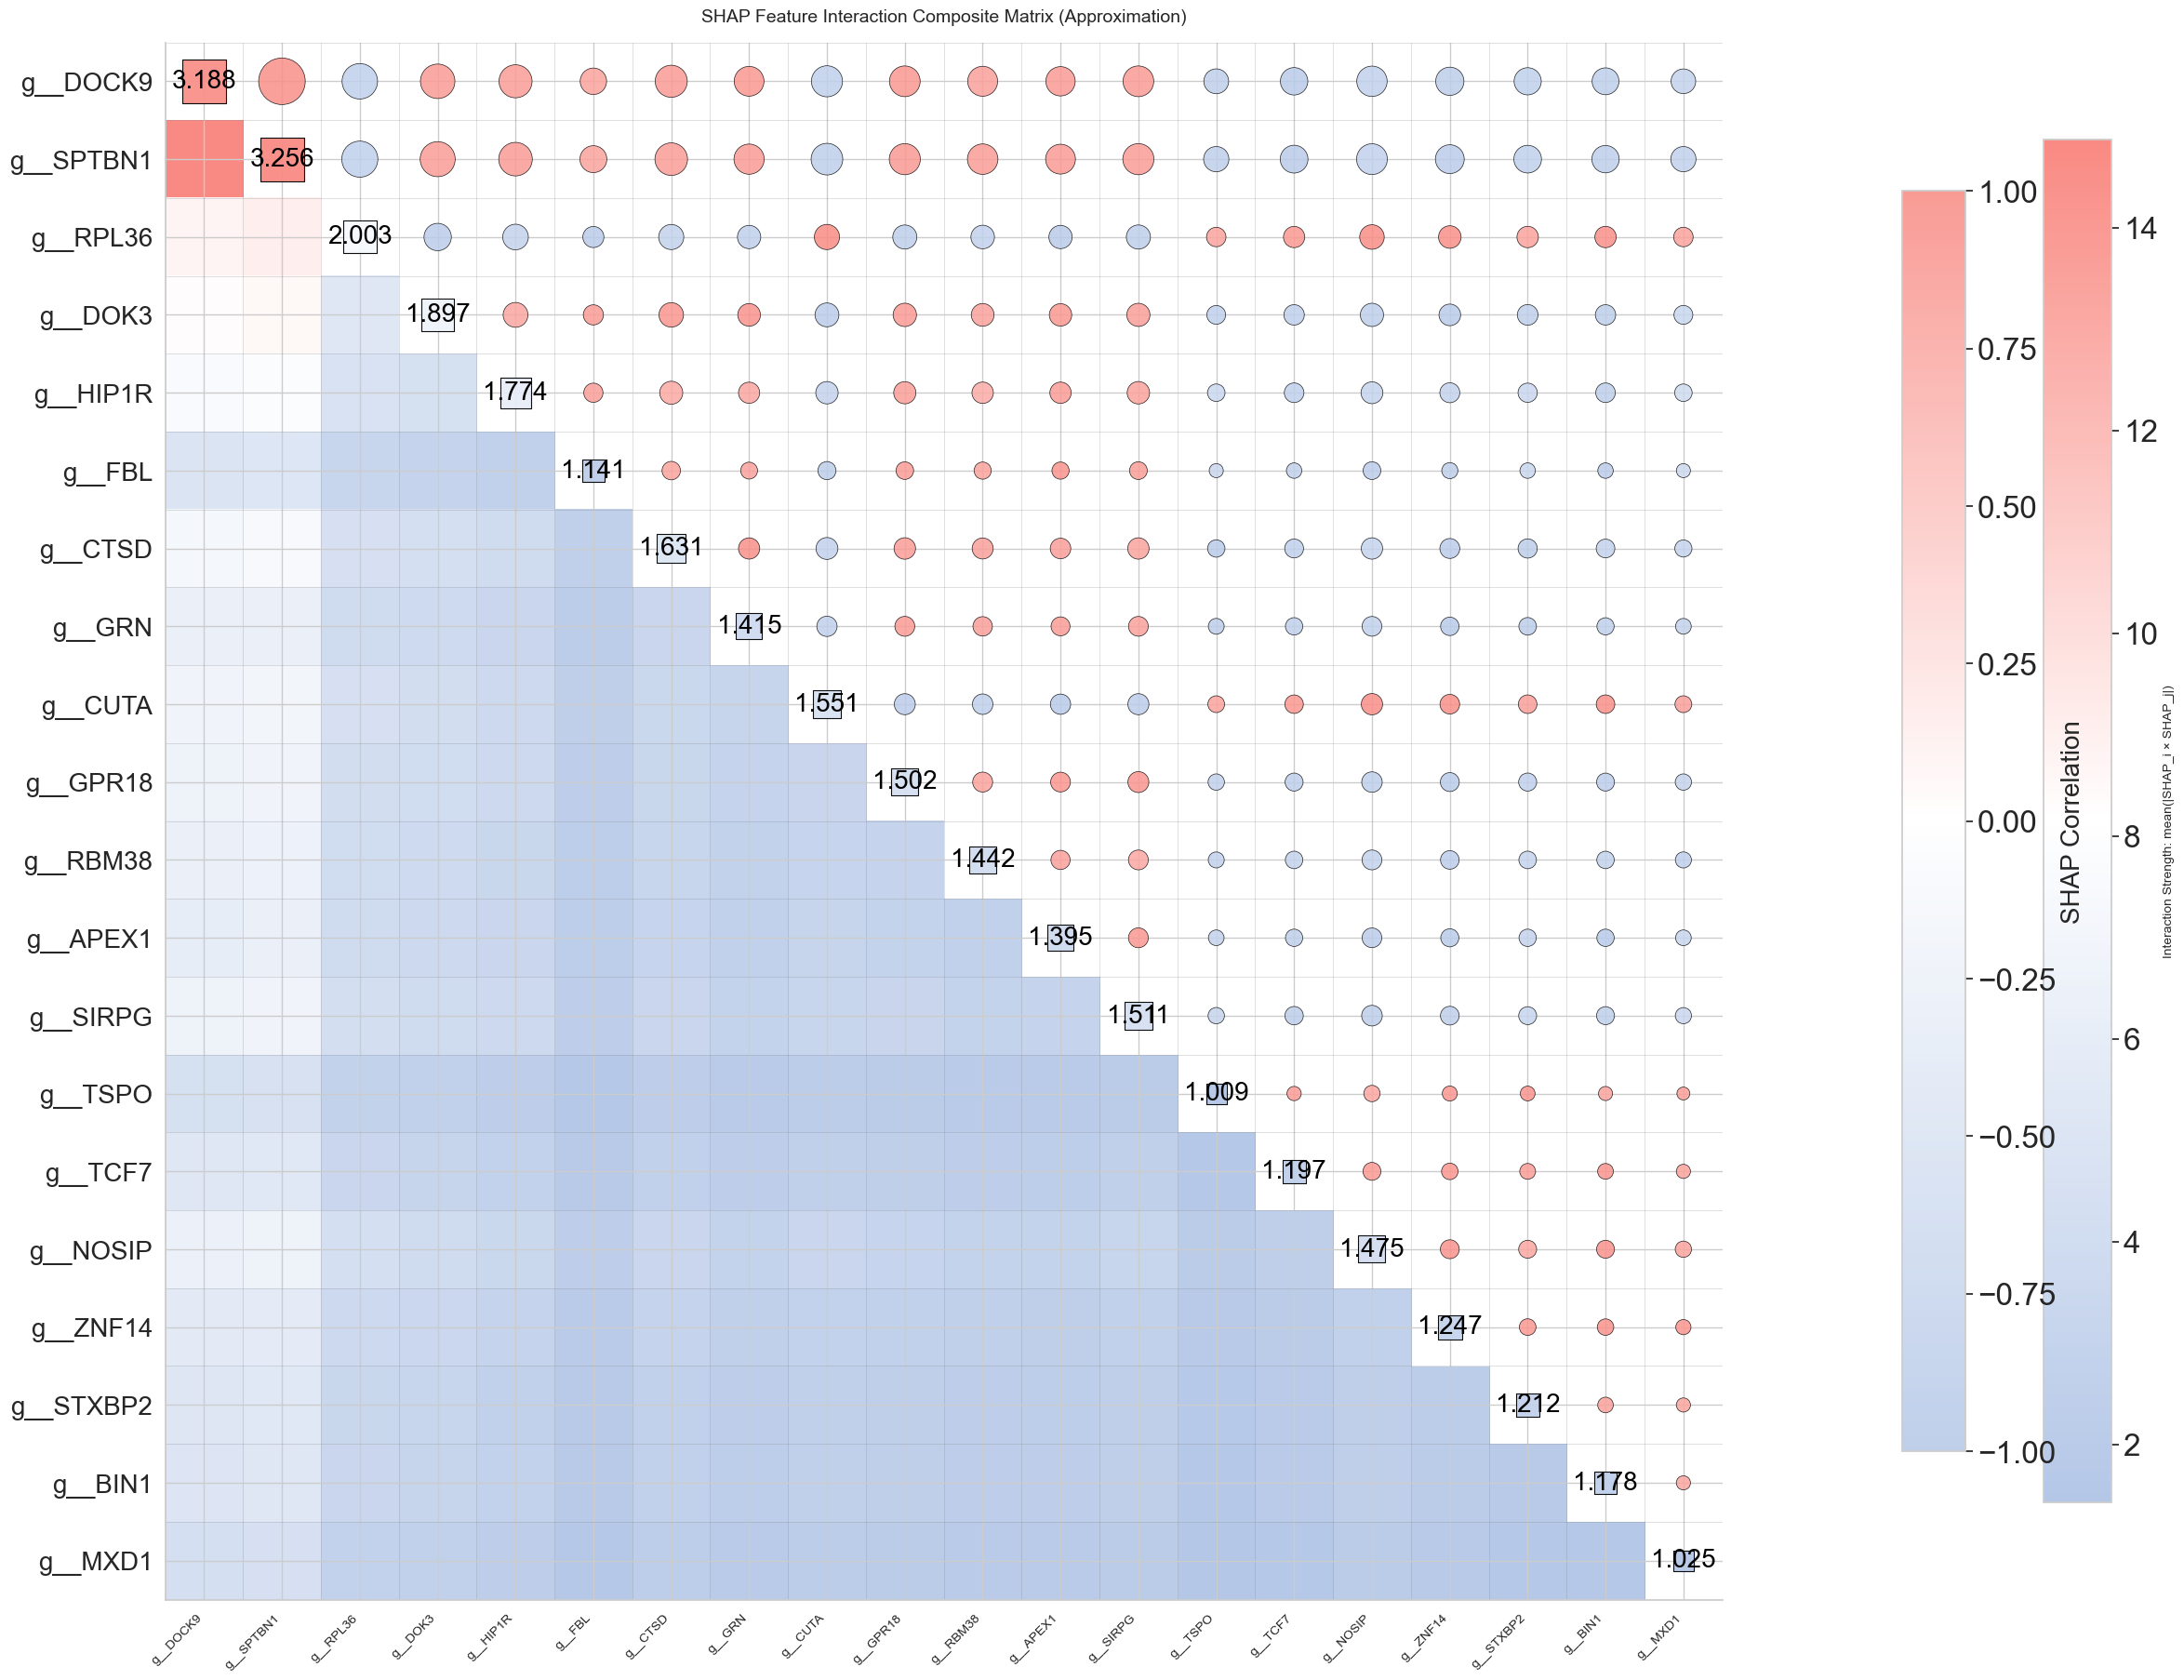

SHAP interaction composite matrix saved to: ./shap_analysis\shap_interaction_composite_matrix.svg


In [506]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


features = shap_df.columns.tolist()
n_feat = len(features)
cmap = LinearSegmentedColormap.from_list(
    "blue_yellow_red", ["#B4C7E7", "white", "#F98A83"]
)

S = shap_df.values  

interaction_strength = np.mean(
    np.abs(S[:, :, None] * S[:, None, :]),
    axis=0
)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=features,
    columns=features
)


corr_df = shap_df.corr(method="pearson")


mean_abs_shap = shap_df.abs().mean(axis=0)


fig, ax = plt.subplots(figsize=(1.0 * n_feat + 4, 1.0 * n_feat + 3))


lower_mask = np.tril(np.ones((n_feat, n_feat), dtype=bool), k=-1)
heat_data = np.full((n_feat, n_feat), np.nan)
heat_data[lower_mask] = interaction_strength[lower_mask]

im = ax.imshow(heat_data, cmap=cmap)


upper_mask = np.triu(np.ones((n_feat, n_feat), dtype=bool), k=1)
upper_i, upper_j = np.where(upper_mask)

upper_interaction = interaction_strength[upper_i, upper_j]
upper_corr = corr_df.values[upper_i, upper_j]

if np.ptp(upper_interaction) == 0:
    bubble_sizes = np.full_like(upper_interaction, 300, dtype=float)
else:
    bubble_sizes = 100 + 1200 * (
        (upper_interaction - upper_interaction.min()) / np.ptp(upper_interaction)
    )

sc = ax.scatter(
    upper_j,
    upper_i,
    s=bubble_sizes,
    c=upper_corr,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.85
)


diag_vals = mean_abs_shap.values
if np.ptp(diag_vals) == 0:
    diag_sizes = np.full_like(diag_vals, 500, dtype=float)
else:
    diag_sizes = 250 + 900 * (
        (diag_vals - diag_vals.min()) / np.ptp(diag_vals)
    )

diag_sc = ax.scatter(
    np.arange(n_feat),
    np.arange(n_feat),
    s=diag_sizes,
    c=diag_vals,
    cmap=cmap,
    marker="s",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.95
)


for i, val in enumerate(diag_vals):
    ax.text(
        i, i, f"{val:.3f}",
        ha="center", va="center",
        fontsize=20, color="black"
    )


ANNOTATE_LOWER = False
if ANNOTATE_LOWER and n_feat <= 12:
    for i in range(n_feat):
        for j in range(n_feat):
            if i > j:
                ax.text(
                    j, i, f"{interaction_strength[i, j]:.3f}",
                    ha="center", va="center",
                    fontsize=7, color="black"
                )


ax.set_xticks(np.arange(n_feat))
ax.set_yticks(np.arange(n_feat))
ax.set_xticklabels(features, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(features, fontsize=20)

ax.set_xlim(-0.5, n_feat - 0.5)
ax.set_ylim(n_feat - 0.5, -0.5)


ax.set_xticks(np.arange(-0.5, n_feat, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_feat, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.35)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("SHAP Feature Interaction Composite Matrix (Approximation)", fontsize=14, pad=16)


cbar1 = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar1.set_label("Interaction Strength: mean(|SHAP_i × SHAP_j|)", fontsize=10)

cbar2 = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.10)
cbar2.set_label("SHAP Correlation", fontsize=20)

plt.tight_layout()

save_path_composite = os.path.join(SAVE_DIR, "shap_interaction_composite_matrix.svg")
plt.savefig(save_path_composite, format="svg", bbox_inches="tight")
plt.show()

print(f"SHAP interaction composite matrix saved to: {save_path_composite}")